In [1]:
import os
import sys
import pyarrow as pa
from pathlib import Path
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import TimeSeriesSplit
from tqdm import tqdm
from joblib import Parallel, delayed
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
sys.path.insert(0, "..")
from paths import resolve

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
_NCPU = os.cpu_count() or 1
pa.set_cpu_count(_NCPU)
pa.set_io_thread_count(_NCPU)
os.environ["NUMEXPR_MAX_THREADS"] = str(_NCPU)
os.environ["NUMEXPR_NUM_THREADS"] = str(_NCPU)
os.environ.setdefault("OMP_NUM_THREADS", str(_NCPU))
os.environ.setdefault("OPENBLAS_NUM_THREADS", str(_NCPU))
os.environ.setdefault("MKL_NUM_THREADS", str(_NCPU))
print(f"Running with {_NCPU} CPU cores | pyarrow {pa.__version__}", flush=True)


Running with 8 CPU cores | pyarrow 24.0.0


Variables

In [2]:
# LOAD DATA
TARGET_COLS = {"nsw_price", "qld_price", "sa_price", "vic_price", "price"}
FEATURE_DATASET_START = pd.Timestamp("2019/01/01")
FEATIRE_DATASET_END = pd.Timestamp("2026/01/01")
os.environ["FEATURE_DATASET"] = "1_dispatch_price.parquet"
os.environ["TARGET"] = "NSW" 
os.environ["TARGETS_PATH"] = resolve(f"3_Targets build/Target_data/{os.environ['TARGET'].lower()}_targets.parquet")
os.environ["FEATURES_PATH"] = resolve(f"2_Features build/Feature_data/{os.environ['FEATURE_DATASET']}")

# AGGREGATE TARGETS
os.environ["OUTPUT_RESOLUTION"] = "30"

# FEATURE RANKING
FEATURE_SELECTION_SUBSAMPLE_START = pd.Timestamp("2019/01/01")
FEATURE_SELECTION_SUBSAMPLE_END = pd.Timestamp("2023/01/01")
FEATURE_RANKING_SUBSAMPLE_AMOUNT = 1_000

# ADD WINDOWS
os.environ["HORIZONS_PER_WINDOW"] = "8"       

# REMOVE DUPLICATE FEATURES
DEDUP_SUBSAMPLE_AMOUNT = 500_000

# FEATURE SELECTION CV
FEATURE_SELECTION_CV_SUBSAMPLE_START = pd.Timestamp("2019/01/01")
FEATURE_SELECTION_CV_SUBSAMPLE_END = pd.Timestamp("2023/01/01")
FEATURE_SELECTION_CV_SUBSAMPLE_AMOUNT = 50_000

# FEATURE SELECTION OUTPUT
os.environ["selected_features_output"] = resolve(f"4_Features select/Selected_features/{os.environ['TARGET']}_selected_features_{os.environ['FEATURE_DATASET']}")


Load raw data

In [3]:
def load_data():
    def load_features(
            feature_dataset_start: pd.Timestamp,
            feature_dataset_end: pd.Timestamp,
    ) -> pd.DataFrame:
        features = pd.read_parquet(os.environ["FEATURES_PATH"], filters=[
            ('SETTLEMENTDATE', '>=', feature_dataset_start),
            ('SETTLEMENTDATE', '<=', feature_dataset_end),
        ])
        
        features = features.drop(columns=[c for c in features.columns if c in TARGET_COLS])
        return features.loc[:feature_dataset_end]


    def load_targets(target:str):
        future_prediction_targets = pd.read_parquet(os.environ["TARGETS_PATH"] )
        return future_prediction_targets


    # Make calls
    features = load_features(
        feature_dataset_start=FEATURE_DATASET_START,
        feature_dataset_end=FEATIRE_DATASET_END,
    )

    future_prediction_targets = load_targets(
        target=os.environ["TARGET"]
    )

    # Align on index
    future_prediction_targets = future_prediction_targets.loc[features.index]
    features = features.loc[future_prediction_targets.index]

    
    display(features[:3])
    display(future_prediction_targets[:3])

    return features, future_prediction_targets

features, future_prediction_targets = load_data()


,nsw_price_asinh_lag_1,nsw_price_asinh_lag_2,nsw_price_asinh_lag_4,nsw_price_asinh_lag_12,nsw_price_asinh_lag_48,nsw_price_asinh_lag_96,nsw_price_asinh_lag_336,nsw_price_asinh_lag_335,nsw_price_asinh_lag_337,nsw_price_asinh_rmean_48,nsw_price_asinh_rmean_336,qld_price_asinh_lag_1,qld_price_asinh_lag_2,qld_price_asinh_lag_4,qld_price_asinh_lag_12,qld_price_asinh_lag_48,qld_price_asinh_lag_96,qld_price_asinh_lag_336,qld_price_asinh_lag_335,qld_price_asinh_lag_337,qld_price_asinh_rmean_48,qld_price_asinh_rmean_336,sa_price_asinh_lag_1,sa_price_asinh_lag_2,sa_price_asinh_lag_4,sa_price_asinh_lag_12,sa_price_asinh_lag_48,sa_price_asinh_lag_96,sa_price_asinh_lag_336,sa_price_asinh_lag_335,sa_price_asinh_lag_337,sa_price_asinh_rmean_48,sa_price_asinh_rmean_336,vic_price_asinh_lag_1,vic_price_asinh_lag_2,vic_price_asinh_lag_4,vic_price_asinh_lag_12,vic_price_asinh_lag_48,vic_price_asinh_lag_96,vic_price_asinh_lag_336,vic_price_asinh_lag_335,vic_price_asinh_lag_337,vic_price_asinh_rmean_48,vic_price_asinh_rmean_336,hour,dayofweek,month,dayofyear,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,is_weekend,is_holiday,is_peak,is_shoulder,is_off_peak,is_offday,nsw_price_lag_1,nsw_price_lag_2,nsw_price_lag_3,nsw_price_lag_4,nsw_price_lag_6,nsw_price_lag_8,nsw_price_lag_12,nsw_price_lag_24,nsw_price_lag_26,nsw_price_lag_28,nsw_price_lag_30,nsw_price_lag_32,nsw_price_lag_34,nsw_price_lag_36,nsw_price_lag_38,nsw_price_lag_40,nsw_price_lag_42,nsw_price_lag_44,nsw_price_lag_46,nsw_price_lag_48,nsw_price_lag_49,nsw_price_lag_50,nsw_price_lag_51,nsw_price_lag_52,nsw_price_lag_54,nsw_price_lag_56,nsw_price_lag_58,nsw_price_lag_60,nsw_price_lag_62,nsw_price_lag_64,nsw_price_lag_66,nsw_price_lag_68,nsw_price_lag_70,nsw_price_lag_96,nsw_price_lag_97,nsw_price_lag_98,nsw_price_lag_143,nsw_price_lag_144,nsw_price_lag_145,nsw_price_lag_191,nsw_price_lag_192,nsw_price_lag_193,nsw_price_lag_335,nsw_price_lag_336,nsw_price_lag_337,nsw_price_lag_671,nsw_price_lag_672,nsw_price_lag_673,qld_price_lag_1,qld_price_lag_2,qld_price_lag_3,qld_price_lag_4,qld_price_lag_6,qld_price_lag_8,qld_price_lag_12,qld_price_lag_24,qld_price_lag_26,qld_price_lag_28,qld_price_lag_30,qld_price_lag_32,qld_price_lag_34,qld_price_lag_36,qld_price_lag_38,qld_price_lag_40,qld_price_lag_42,qld_price_lag_44,qld_price_lag_46,qld_price_lag_48,qld_price_lag_49,qld_price_lag_50,qld_price_lag_51,qld_price_lag_52,qld_price_lag_54,qld_price_lag_56,qld_price_lag_58,qld_price_lag_60,qld_price_lag_62,qld_price_lag_64,qld_price_lag_66,qld_price_lag_68,qld_price_lag_70,qld_price_lag_96,qld_price_lag_97,qld_price_lag_98,qld_price_lag_143,qld_price_lag_144,qld_price_lag_145,qld_price_lag_191,qld_price_lag_192,qld_price_lag_193,qld_price_lag_335,qld_price_lag_336,qld_price_lag_337,qld_price_lag_671,qld_price_lag_672,qld_price_lag_673,sa_price_lag_1,sa_price_lag_2,sa_price_lag_3,sa_price_lag_4,sa_price_lag_6,sa_price_lag_8,sa_price_lag_12,sa_price_lag_24,sa_price_lag_26,sa_price_lag_28,sa_price_lag_30,sa_price_lag_32,sa_price_lag_34,sa_price_lag_36,sa_price_lag_38,sa_price_lag_40,sa_price_lag_42,sa_price_lag_44,sa_price_lag_46,sa_price_lag_48,sa_price_lag_49,sa_price_lag_50,sa_price_lag_51,sa_price_lag_52,sa_price_lag_54,sa_price_lag_56,sa_price_lag_58,sa_price_lag_60,sa_price_lag_62,sa_price_lag_64,sa_price_lag_66,sa_price_lag_68,sa_price_lag_70,sa_price_lag_96,sa_price_lag_97,sa_price_lag_98,sa_price_lag_143,sa_price_lag_144,sa_price_lag_145,sa_price_lag_191,sa_price_lag_192,sa_price_lag_193,sa_price_lag_335,sa_price_lag_336,sa_price_lag_337,sa_price_lag_671,sa_price_lag_672,sa_price_lag_673,vic_price_lag_1,vic_price_lag_2,vic_price_lag_3,vic_price_lag_4,vic_price_lag_6,vic_price_lag_8,vic_price_lag_12,vic_price_lag_24,vic_price_lag_26,vic_price_lag_28,vic_price_lag_30,vic_price_lag_32,vic_price_lag_34,vic_price_lag_36,vic_price_lag_38,vic_price_lag_40,vic_price_lag_42,vic_price_lag_44,vic_price_lag_46,vic_price_lag_48,vic_price_lag_49,vic_price_lag_50,vic_price_lag_51,vic_price_lag_52,vic_price

,target_h1,target_h2,target_h3,target_h4,target_h5,target_h6,target_h7,target_h8,target_h9,target_h10,target_h11,target_h12,target_h13,target_h14,target_h15,target_h16,target_h17,target_h18,target_h19,target_h20,target_h21,target_h22,target_h23,target_h24,target_h25,target_h26,target_h27,target_h28,target_h29,target_h30,target_h31,target_h32,target_h33,target_h34,target_h35,target_h36,target_h37,target_h38,target_h39,target_h40,target_h41,target_h42,target_h43,target_h44,target_h45,target_h46,target_h47,target_h48,target_h49,target_h50,target_h51,target_h52,target_h53,target_h54,target_h55,target_h56,target_h57,target_h58,target_h59,target_h60,target_h61,target_h62,target_h63,target_h64,target_h65,target_h66,target_h67,target_h68,target_h69,target_h70,target_h71,target_h72,target_h73,target_h74,target_h75,target_h76,target_h77,target_h78,target_h79,target_h80,target_h81,target_h82,target_h83,target_h84,target_h85,target_h86,target_h87,target_h88,target_h89,target_h90,target_h91,target_h92,target_h93,target_h94,target_h95,target_h96,target_h97,target_h98,target_h99,target_h100,target_h101,target_h102,target_h103,target_h104,target_h105,target_h106,target_h107,target_h108,target_h109,target_h110,target_h111,target_h112,target_h113,target_h114,target_h115,target_h116,target_h117,target_h118,target_h119,target_h120,target_h121,target_h122,target_h123,target_h124,target_h125,target_h126,target_h127,target_h128,target_h129,target_h130,target_h131,target_h132,target_h133,target_h134,target_h135,target_h136,target_h137,target_h138,target_h139,target_h140,target_h141,target_h142,target_h143,target_h144,target_h145,target_h146,target_h147,target_h148,target_h149,target_h150,target_h151,target_h152,target_h153,target_h154,target_h155,target_h156,target_h157,target_h158,target_h159,target_h160,target_h161,target_h162,target_h163,target_h164,target_h165,target_h166,target_h167,target_h168,target_h169,target_h170,target_h171,target_h172,target_h173,target_h174,target_h175,target_h176,target_h177,target_h178,target_h179,target_h180,target_h181,target_h182,target_h183,target_h184,target_h185,target_h186,target_h187,target_h188,target_h189,target_h190,target_h191,target_h192,target_h193,target_h194,target_h195,target_h196,target_h197,target_h198,target_h199,target_h200,target_h201,target_h202,target_h203,target_h204,target_h205,target_h206,target_h207,target_h208,target_h209,target_h210,target_h211,target_h212,target_h213,target_h214,target_h215,target_h216,target_h217,target_h218,target_h219,target_h220,target_h221,target_h222,target_h223,target_h224,target_h225,target_h226,target_h227,target_h228,target_h229,target_h230,target_h231,target_h232,target_h233,target_h234,target_h235,target_h236,target_h237,target_h238,target_h239,target_h240,target_h241,target_h242,target_h243,target_h244,target_h245,target_h246,target_h247,target_h248,target_h249,target_h250,target_h251,target_h252,target_h253,target_h254,target_h255,target_h256,target_h257,target_h258,target_h259,target_h260,target_h261,target_h262,target_h263,target_h264,target_h265,target_h266,target_h267,target_h268,target_h269,target_h270,target_h271,target_h272,target_h273,target_h274,target_h275,target_h276,target_h277,target_h278,target_h279,target_h280,target_h281,target_h282,target_h283,target_h284,target_h285,target_h286,target_h287,target_h288,target_h289,target_h290,target_h291,target_h292,target_h293,target_h294,target_h295,target_h296,target_h297,target_h298,target_h299,target_h300,target_h301,target_h302,target_h303,target_h304,target_h305,target_h306,target_h307,target_h308,target_h309,target_h310,target_h311,target_h312,target_h313,target_h314,target_h315,target_h316,target_h317,target_h318,target_h319,target_h320,target_h321,target_h322,target_h323,target_h324,target_h325,target_h326,target_h327,target_h328,target_h329,target_h330,target_h331,target_h332,target_h333,target_h334,target_h335,target_h336,target_h337,target_h338,target_h339,target_h340,target_h341,target_h342,tar

Aggregate targets to output resolution

In [4]:
def aggregate_targets(future_prediction_targets):
    OUTPUT_RESOLUTION = int(os.environ["OUTPUT_RESOLUTION"])

    target_cols = list(future_prediction_targets.columns)
    horizons = len(target_cols)
    bucket_size = max(1, OUTPUT_RESOLUTION // 5)
    n_buckets = horizons // bucket_size
    n_raw = n_buckets * bucket_size

    values = future_prediction_targets.values.astype(np.float32)
    aggregated = values[:, :n_raw].reshape(len(values), n_buckets, bucket_size).mean(axis=2)
    bucket_cols = [f"h{i + 1}" for i in range(n_buckets)]

    future_prediction_targets_agg = pd.DataFrame(
        aggregated,
        index=future_prediction_targets.index,
        columns=bucket_cols,
    )
    display(future_prediction_targets_agg[:3])

    return future_prediction_targets_agg


future_prediction_targets_agg = aggregate_targets(future_prediction_targets)


,h1,h2,h3,h4,h5,h6,h7,h8,h9,h10,h11,h12,h13,h14,h15,h16,h17,h18,h19,h20,h21,h22,h23,h24,h25,h26,h27,h28,h29,h30,h31,h32,h33,h34,h35,h36,h37,h38,h39,h40,h41,h42,h43,h44,h45,h46,h47,h48,h49,h50,h51,h52,h53,h54,h55,h56,h57,h58,h59,h60,h61,h62,h63,h64,h65,h66,h67,h68,h69,h70,h71,h72,h73,h74,h75,h76,h77,h78,h79,h80,h81,h82,h83,h84,h85,h86,h87,h88,h89,h90,h91,h92,h93,h94,h95,h96
SETTLEMENTDATE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,66.771278,68.736610,71.561913,71.393814,67.557159,64.376251,62.394154,51.286774,53.846653,50.875000,47.969280,48.631649,53.432526,45.549961,48.958332,51.223370,51.833328,48.756680,60.809326,59.242542,65.243538,68.419991,75.266632,87.591408,91.870003,91.864998,96.619423,93.356079,97.833595,91.971046,92.450439,103.648804,96.037132,98.407753,94.583717,108.256554,131.045959,128.823776,115.016685,100.055275,103.012024,100.274956,92.320435,73.138535,99.104866,82.169136,73.394318,77.301506,75.259422,64.210213,59.465015,47.683834,51.239410,50.860371,59.252514,62.060055,64.291313,65.579994,71.565880,81.070984,91.964966,91.866676,95.826576,100.625389,93.834862,91.866402,93.166344,91.597313,102.530182,104.611305,99.189972,119.451965,107.280708,190.787033,116.456909,109.511574,119.361382,109.234642,95.479492,90.175728,95.548737,116.989037,106.786232,117.873390,113.989891,108.508858,92.866425,97.089691,103.439690,88.767456,92.471924,84.447395,83.185814,77.843376,82.700470,83.707741
2019-01-01 00:05:00,66.948692,69.325172,72.795120,70.308716,66.977119,63.867970,62.197407,50.223507,53.750000,50.291199,47.594746,48.631649,53.165852,45.816639,48.958332,52.181702,48.208328,53.693905,61.014042,59.082264,66.331871,68.419983,77.274132,89.492249,91.870003,91.865013,96.619408,95.499756,95.796013,92.960350,91.353424,107.507141,101.868797,90.780479,93.913124,116.015472,123.430626,131.148041,112.496300,98.715637,103.012024,98.463295,90.303764,71.576836,103.538185,77.847908,74.765587,77.301506,75.448257,62.531376,59.465015,45.770496,46.445858,56.444309,59.420460,63.416718,66.012993,65.709991,71.590874,84.189323,91.966637,93.946388,95.323128,100.596924,92.285393,91.866402,93.166344,91.739571,106.246269,102.106598,98.835594,122.312744,113.110687,186.801590,112.145149,110.525116,120.815010,108.244659,92.611168,90.630096,100.930061,115.010002,106.786232,123.650879,106.240868,107.143730,91.706970,100.394188,100.545265,88.016846,92.490990,82.436005,82.249817,77.553726,85.163582,81.877991
2019-01-01 00:10:00,67.518059,68.807365,73.763771,69.035126,66.897430,63.167255,59.882412,51.181843,53.749989,46.666153,50.261459,49.744980,51.004200,46.864960,48.691692,52.448345,48.208332,55.360569,60.305710,60.450977,67.408142,68.992020,79.430977,90.671715,91.868340,91.865013,96.619408,96.980896,94.316528,93.281982,91.520119,107.017143,100.057121,96.450478,91.328819,122.128685,125.733406,125.318054,111.361259,99.099724,101.881401,96.484871,89.468361,76.272255,98.524605,75.094818,78.341927,75.372368,72.712700,62.531399,59.063328,43.857162,46.445877,57.402622,61.157246,62.240479,66.160767,68.209999,70.827545,88.095978,91.968300,93.944733,95.323120,100.596924,92.285400,91.866394,93.166351,91.695747,107.887108,104.367897,96.085060,125.064980,118.940666,180.969925,109.530724,110.182228,122.188683,106.405327,91.435066,90.392509,105.766731,114.030113,107.766121,123.650879,106.458649,103.589272,91.037514,104.401970,97.206940,86.694427,92.930786,82.382881,81.375237,78.000168,85.375366,77.760040


Feature ranking

In [5]:
"""
Rank features

MI ranking: measures mutual information — a non-linear, information-theoretic score. It answers "does knowing this feature reduce uncertainty about the target?",
capturing non-linear dependencies too. Targets are passed in pre-aggregated to output_resolution_minutes,
so MI is computed directly at the output resolution.
"""

def rank_features(features:pd.DataFrame,
    future_prediction_targets_agg: pd.DataFrame,
    feature_selection_subsample_start: pd.Timestamp,
    feature_selection_subsample_end: pd.Timestamp,
    feature_selection_subsample_amount: int,
    output_resolution_minutes: int,
):
    
    target_rounds = 10

    feature_cols = list(features.columns)
    target_cols_agg = list(future_prediction_targets_agg.columns)
    n_buckets = len(target_cols_agg)

    def _filter_data_for_feature_time_range_subset():
        features_subset = features.loc[feature_selection_subsample_start:feature_selection_subsample_end]
        targets_subset = future_prediction_targets_agg.loc[feature_selection_subsample_start:feature_selection_subsample_end]
        shared_index = features_subset.index.intersection(targets_subset.index)
        return features_subset.loc[shared_index], targets_subset.loc[shared_index]

    features_subset, targets_subset = _filter_data_for_feature_time_range_subset()

    features_subset = features_subset.values.astype(np.float32)
    targets_subset = targets_subset.reset_index(drop=True)

    def _subsample_features():
        seed = np.random.default_rng(42)
        n_samples = min(feature_selection_subsample_amount, len(features_subset))
        subsample_index = seed.choice(len(features_subset), size=n_samples, replace=False)
        subsample_index.sort()
        return features_subset[subsample_index], targets_subset.iloc[subsample_index]

    X_subsample, y_subsample = _subsample_features()

    def _mutual_information_scoring():
        aggregated_target_matrix = y_subsample[target_cols_agg].values.astype(np.float32)
        n_features = X_subsample.shape[1]
        n_subsample_rows = X_subsample.shape[0]

        # Split features into chunks so n_tasks >> n_workers → multiple rounds
        n_feature_chunks = max(1, (target_rounds * _NCPU + n_buckets - 1) // n_buckets)
        chunk_edges = np.array_split(np.arange(n_features), n_feature_chunks)
        feature_chunk_ranges = [(int(c[0]), int(c[-1]) + 1) for c in chunk_edges if len(c) > 0]
        n_tasks = n_buckets * len(feature_chunk_ranges)

        print(
            f"  MI scoring: {n_features} features × {n_buckets} horizons ({output_resolution_minutes}-min) "
            f"| subsample n={n_subsample_rows:,} | {n_tasks} tasks across {_NCPU} CPUs (~{n_tasks // _NCPU} rounds)",
            flush=True,
        )

        def _score_chunk(bucket_idx, feature_start_idx, feature_end_idx):
            return bucket_idx, feature_start_idx, feature_end_idx, mutual_info_regression(
                X_subsample[:, feature_start_idx:feature_end_idx], aggregated_target_matrix[:, bucket_idx],
                discrete_features=False, n_neighbors=3, random_state=42,
            )

        gen = Parallel(n_jobs=-1, backend="loky", batch_size=1, return_as="generator_unordered")(
            delayed(_score_chunk)(bucket_idx, feature_start_idx, feature_end_idx)
            for bucket_idx in range(n_buckets) for feature_start_idx, feature_end_idx in feature_chunk_ranges
        )
        scores = np.empty((n_features, n_buckets))
        for bucket_idx, feature_start_idx, feature_end_idx, chunk_scores in tqdm(gen, total=n_tasks, desc="MI scoring", leave=True):
            scores[feature_start_idx:feature_end_idx, bucket_idx] = chunk_scores

        mi_matrix = pd.DataFrame(scores, index=feature_cols, columns=target_cols_agg)
        feature_cols_ranked = mi_matrix.mean(axis=1).sort_values(ascending=False)
        return feature_cols_ranked, mi_matrix

    feature_cols_ranked, mi_matrix = _mutual_information_scoring()

    df = pd.DataFrame({
        "rank": range(1, len(feature_cols_ranked) + 1),
        "feature": feature_cols_ranked.index,
        "mean_mi": feature_cols_ranked.values,
        "target": os.environ["TARGET"],
        "feature_dataset": Path(os.environ["FEATURE_DATASET"]).stem,
    }).set_index("feature")

    df_horizons = mi_matrix.reindex(feature_cols_ranked.index)
    feature_data = pd.concat([df, df_horizons], axis=1).reset_index(names="feature")

    display(feature_data[:3])
    return feature_data

feature_data = rank_features(
    features=features,
    future_prediction_targets_agg=future_prediction_targets_agg,
    feature_selection_subsample_start=FEATURE_SELECTION_SUBSAMPLE_START,
    feature_selection_subsample_end=FEATURE_SELECTION_SUBSAMPLE_END,
    feature_selection_subsample_amount=FEATURE_RANKING_SUBSAMPLE_AMOUNT,
    output_resolution_minutes=int(os.environ["OUTPUT_RESOLUTION"]),
)



  MI scoring: 634 features × 96 horizons (30-min) | subsample n=1,000 | 96 tasks across 8 CPUs (~12 rounds)


MI scoring: 100%|██████████| 96/96 [00:24<00:00,  3.95it/s]


,feature,rank,mean_mi,target,feature_dataset,h1,h2,h3,h4,h5,h6,h7,h8,h9,h10,h11,h12,h13,h14,h15,h16,h17,h18,h19,h20,h21,h22,h23,h24,h25,h26,h27,h28,h29,h30,h31,h32,h33,h34,h35,h36,h37,h38,h39,h40,h41,h42,h43,h44,h45,h46,h47,h48,h49,h50,h51,h52,h53,h54,h55,h56,h57,h58,h59,h60,h61,h62,h63,h64,h65,h66,h67,h68,h69,h70,h71,h72,h73,h74,h75,h76,h77,h78,h79,h80,h81,h82,h83,h84,h85,h86,h87,h88,h89,h90,h91,h92,h93,h94,h95,h96
0,nsw_price_q90_336,1,0.520032,NSW,1_dispatch_price,0.642081,0.589403,0.611350,0.620653,0.582265,0.577282,0.569113,0.562880,0.559270,0.526846,0.553539,0.527778,0.527400,0.462414,0.531032,0.535137,0.535320,0.527342,0.599072,0.537092,0.542472,0.611406,0.549680,0.607448,0.596546,0.505247,0.508167,0.526657,0.471996,0.485707,0.461973,0.453399,0.475934,0.473168,0.510491,0.561398,0.560235,0.550963,0.558377,0.568222,0.606966,0.586494,0.604233,0.552777,0.585439,0.579696,0.592701,0.554512,0.492356,0.553480,0.561592,0.533400,0.467711,0.485854,0.450755,0.485576,0.487768,0.429216,0.444892,0.479089,0.465724,0.459340,0.463678,0.436292,0.419428,0.498793,0.500654,0.491970,0.555001,0.507277,0.470142,0.475673,0.506308,0.480966,0.453410,0.438656,0.417932,0.418802,0.481689,0.471094,0.478408,0.451781,0.530644,0.517987,0.579305,0.531172,0.485033,0.487083,0.503964,0.538901,0.517936,0.537947,0.532404,0.513733,0.507645,0.505061
1,nsw_price_asinh_rmean_336,2,0.508457,NSW,1_dispatch_price,0.669668,0.601920,0.612534,0.636281,0.627400,0.601567,0.624224,0.540811,0.537632,0.523939,0.526626,0.527934,0.514671,0.525278,0.517664,0.516195,0.486623,0.531660,0.556299,0.523825,0.540229,0.512724,0.565422,0.523272,0.551111,0.512797,0.484811,0.512637,0.470028,0.464717,0.450288,0.460500,0.489705,0.546980,0.546631,0.575655,0.524799,0.536079,0.551488,0.537154,0.582216,0.593880,0.580602,0.556457,0.543631,0.570113,0.535440,0.577510,0.475813,0.491969,0.485420,0.506332,0.470341,0.498873,0.474476,0.459533,0.452788,0.479713,0.437834,0.421766,0.426041,0.451613,0.457722,0.462982,0.475821,0.492980,0.487037,0.483651,0.539279,0.481138,0.457238,0.489295,0.422522,0.492058,0.445113,0.442738,0.428636,0.399256,0.420610,0.463200,0.456595,0.436282,0.497134,0.475553,0.483733,0.448766,0.499841,0.500438,0.471376,0.495269,0.492289,0.545606,0.504920,0.498430,0.510044,0.522200
2,nsw_price_rmean_2016,3,0.496085,NSW,1_dispatch_price,0.527689,0.566931,0.505186,0.548956,0.533929,0.547354,0.498999,0.514184,0.565817,0.535580,0.503777,0.527859,0.483552,0.513701,0.499600,0.539287,0.548703,0.513125,0.533715,0.574611,0.527763,0.513766,0.524695,0.505945,0.508257,0.507659,0.471340,0.508754,0.497336,0.495440,0.452167,0.401541,0.453020,0.511102,0.453084,0.491286,0.521304,0.485608,0.501109,0.468756,0.525776,0.540875,0.527598,0.474595,0.534144,0.486363,0.509003,0.469705,0.433704,0.443740,0.477701,0.517582,0.453206,0.534580,0.483386,0.472560,0.472733,0.459443,0.428083,0.497421,0.447383,0.485964,0.456664,0.471321,0.496966,0.544277,0.481334,0.512906,0.527601,0.497474,0.456383,0.532066,0.475015,0.458292,0.459867,0.447893,0.506253,0.442617,0.475158,0.490255,0.442631,0.500104,0.500882,0.495819,0.490455,0.519124,0.523606,0.492460,0.485441,0.473860,0.505556,0.482530,0.471714,0.476842,0.479530,0.493238


Correlation matrix

In [ ]:
if True:
    def add_windows():
        HORIZONS_PER_WINDOW = int(os.environ["HORIZONS_PER_WINDOW"])
        OUTPUT_RESOLUTION = int(os.environ["OUTPUT_RESOLUTION"])

        _fd = feature_data
        horizon_cols = [c for c in _fd.columns if c.startswith("h") and c[1:].isdigit()]
        n_windows = len(horizon_cols) // HORIZONS_PER_WINDOW
        mi_df = _fd.set_index("feature")[horizon_cols]

        window_selections = {}
        window_mi_matrices = {}

        for w in range(n_windows):
            start_h = w * HORIZONS_PER_WINDOW
            end_h = start_h + HORIZONS_PER_WINDOW
            win_cols = horizon_cols[start_h:end_h]

            start_min = start_h * OUTPUT_RESOLUTION
            end_min = end_h * OUTPUT_RESOLUTION
            label = f"{start_min // 60}–{end_min // 60}h"

            win_mi = mi_df[win_cols]
            window_mi_matrices[label] = win_mi
            window_selections[label] = win_mi.mean(axis=1).sort_values(ascending=False).index.tolist()

        return window_selections, window_mi_matrices

    window_selections, window_mi_matrices = add_windows()


In [ ]:
if True:
    def mi_matrix_facets(window_selections: dict, window_mi_matrices: dict, top_n: int = 20, ncols: int = 4):
        """All window MI heatmaps in one faceted figure with a shared colorbar."""
        labels = list(window_selections.keys())
        nrows  = (len(labels) + ncols - 1) // ncols

        _cmap = LinearSegmentedColormap.from_list(
            "mi_vibrant", ["#0a0a1a", "#2e1a6e", "#7b2d8b", "#d63a6e", "#f4845f"], N=256
        )

        # Pre-normalise each window's MI matrix, sorted by window MI, top_n features
        win_norms = {}
        for label, feats in window_selections.items():
            mi_win = window_mi_matrices[label].loc[feats]
            mi_win = mi_win.loc[mi_win.mean(axis=1).sort_values(ascending=False).index]
            win_norms[label] = (1 - np.exp(-mi_win)).head(top_n)

        col_w   = 9
        row_h   = max(3.5, top_n * 0.27)
        CBAR_H  = 0.1
        TITLE_H = 0.001   # extra space at top for the suptitle

        with plt.style.context("dark_background"):
            fig = plt.figure(figsize=(col_w * ncols, row_h * nrows + CBAR_H + TITLE_H))
            fig.patch.set_facecolor("#1e1e1e")

            gs = fig.add_gridspec(
                nrows + 1, ncols,
                height_ratios=[CBAR_H] + [row_h] * nrows,
                hspace=0.25, wspace=0.35,
                top=0.90,
            )
            cax = fig.add_subplot(gs[0, :])

            for idx, label in enumerate(labels):
                r = idx // ncols + 1
                c = idx % ncols
                ax = fig.add_subplot(gs[r, c])
                ax.set_facecolor("#1e1e1e")

                data       = win_norms[label]
                n_feat     = data.shape[0]
                annot_size = max(5, min(9, int(160 / max(n_feat, 1))))
                y_size     = max(6, min(9, int(200 / max(n_feat, 1))))

                sns.heatmap(
                    data, ax=ax, cmap=_cmap, vmin=0, vmax=1,
                    annot=True, fmt=".2f",
                    annot_kws={"size": annot_size, "color": "white"},
                    linewidths=0, linecolor="#2e2e2e", cbar=False,
                )
                ax.set_title(label, color="white", fontsize=10, pad=6)
                ax.xaxis.set_ticks_position("top")
                ax.xaxis.set_label_position("top")
                ax.tick_params(axis="x", labelsize=7, rotation=45, colors="white")
                ax.tick_params(axis="y", labelsize=y_size, rotation=0, colors="white")
                plt.setp(ax.get_xticklabels(), ha="left")

            # Shared colorbar in the top strip
            sm   = plt.cm.ScalarMappable(cmap=_cmap, norm=plt.Normalize(vmin=0, vmax=1))
            cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
            cax.xaxis.set_ticks_position("top")
            cax.xaxis.set_label_position("top")
            cbar.set_label("MI  (1 − e⁻ᴹᴵ)  —  normalised per feature", color="white", labelpad=6)
            cbar.ax.tick_params(colors="white")

            _window_hours = int(os.environ['HORIZONS_PER_WINDOW']) * int(os.environ['OUTPUT_RESOLUTION']) // 60
            fig.suptitle(
                f"Feature–target MI by {_window_hours}-hour window  (top {top_n} features per window)",
                color="white", fontsize=14, y=0.97,
            )
            plt.show()


    mi_matrix_facets(window_selections, window_mi_matrices, top_n=20, ncols=2)


Remove duplicate features (post-ranking)

In [8]:
def remove_duplicate_features(feature_data, features_full):
    LINEAR_CORR_THRESHOLD = 0.95     # |Pearson| above this → linear duplicate
    NONLINEAR_CORR_THRESHOLD = 0.95  # |Spearman| above this → monotonic non-linear duplicate

    ranked_features = feature_data["feature"].tolist()  # already sorted best → worst by mean_mi

    cols_present = [f for f in ranked_features if f in features_full.columns]
    features_full = features_full[cols_present]

    n_rows_total = len(features_full)
    n_rows = min(DEDUP_SUBSAMPLE_AMOUNT, n_rows_total)
    if n_rows < n_rows_total:
        rng = np.random.default_rng(42)
        subsample_idx = np.sort(rng.choice(n_rows_total, size=n_rows, replace=False))
        features_full = features_full.iloc[subsample_idx]

    n_rows, n_features = features_full.shape
    print(
        f"Standardising {n_rows:,} rows × {n_features} features "
        f"(subsample of {n_rows_total:,} total rows)...",
        flush=True,
    )

    # Standardise columns → Pearson corr = (Z.T @ Z) / n_rows per column pair
    col_means = features_full.mean()
    col_stds = features_full.std().replace(0, 1)
    Z_pearson = ((features_full - col_means) / col_stds).values.astype(np.float32)

    # Rank then standardise → Spearman via same dot product trick
    ranks = features_full.rank()
    rank_means = ranks.mean()
    rank_stds = ranks.std().replace(0, 1)
    Z_spearman = ((ranks - rank_means) / rank_stds).values.astype(np.float32)

    col_index = {col: i for i, col in enumerate(cols_present)}

    kept_indices = []  # column positions of kept features in Z_pearson / Z_spearman
    duplicate_flags = {}

    for feature in tqdm(ranked_features, desc="Deduplicating features", leave=True):
        if feature not in col_index:
            # feature absent from the loaded parquet — keep unconditionally
            duplicate_flags[feature] = False
            continue
        fi = col_index[feature]
        if not kept_indices:
            duplicate_flags[feature] = False
            kept_indices.append(fi)
            continue

        kept_arr = np.array(kept_indices)
        # Dot candidate column against each kept column → correlation vector; O(n_kept × n_rows)
        pearson_vals = np.abs(Z_pearson[:, fi] @ Z_pearson[:, kept_arr]) / n_rows
        spearman_vals = np.abs(Z_spearman[:, fi] @ Z_spearman[:, kept_arr]) / n_rows
        is_dup = bool(pearson_vals.max() > LINEAR_CORR_THRESHOLD or spearman_vals.max() > NONLINEAR_CORR_THRESHOLD)
        duplicate_flags[feature] = is_dup
        if not is_dup:
            kept_indices.append(fi)

    feature_data_flagged = feature_data.copy()
    feature_data_flagged["is_duplicate"] = feature_data_flagged["feature"].map(duplicate_flags)

    n_kept = feature_data_flagged["is_duplicate"].eq(False).sum()
    n_removed = feature_data_flagged["is_duplicate"].eq(True).sum()
    print(
        f"Kept {n_kept} unique features, flagged {n_removed} duplicates "
        f"(Pearson threshold={LINEAR_CORR_THRESHOLD}, Spearman threshold={NONLINEAR_CORR_THRESHOLD})",
        flush=True,
    )

    feature_data_unique = feature_data_flagged[feature_data_flagged["is_duplicate"] == False].reset_index(drop=True)

    display(feature_data_unique[:3])

    return feature_data_unique, feature_data_flagged, features_full


feature_data_unique, feature_data_flagged, features_subsampled = remove_duplicate_features(feature_data, features)


Standardising 500,000 rows × 634 features (subsample of 736,417 total rows)...


Deduplicating features: 100%|██████████| 634/634 [01:07<00:00,  9.35it/s]


Kept 438 unique features, flagged 196 duplicates (Pearson threshold=0.95, Spearman threshold=0.95)


,feature,rank,mean_mi,target,feature_dataset,h1,h2,h3,h4,h5,h6,h7,h8,h9,h10,h11,h12,h13,h14,h15,h16,h17,h18,h19,h20,h21,h22,h23,h24,h25,h26,h27,h28,h29,h30,h31,h32,h33,h34,h35,h36,h37,h38,h39,h40,h41,h42,h43,h44,h45,h46,h47,h48,h49,h50,h51,h52,h53,h54,h55,h56,h57,h58,h59,h60,h61,h62,h63,h64,h65,h66,h67,h68,h69,h70,h71,h72,h73,h74,h75,h76,h77,h78,h79,h80,h81,h82,h83,h84,h85,h86,h87,h88,h89,h90,h91,h92,h93,h94,h95,h96,is_duplicate
0,nsw_price_q90_336,1,0.520032,NSW,1_dispatch_price,0.642081,0.589403,0.611350,0.620653,0.582265,0.577282,0.569113,0.562880,0.559270,0.526846,0.553539,0.527778,0.527400,0.462414,0.531032,0.535137,0.535320,0.527342,0.599072,0.537092,0.542472,0.611406,0.549680,0.607448,0.596546,0.505247,0.508167,0.526657,0.471996,0.485707,0.461973,0.453399,0.475934,0.473168,0.510491,0.561398,0.560235,0.550963,0.558377,0.568222,0.606966,0.586494,0.604233,0.552777,0.585439,0.579696,0.592701,0.554512,0.492356,0.553480,0.561592,0.533400,0.467711,0.485854,0.450755,0.485576,0.487768,0.429216,0.444892,0.479089,0.465724,0.459340,0.463678,0.436292,0.419428,0.498793,0.500654,0.491970,0.555001,0.507277,0.470142,0.475673,0.506308,0.480966,0.453410,0.438656,0.417932,0.418802,0.481689,0.471094,0.478408,0.451781,0.530644,0.517987,0.579305,0.531172,0.485033,0.487083,0.503964,0.538901,0.517936,0.537947,0.532404,0.513733,0.507645,0.505061,False
1,nsw_price_asinh_rmean_336,2,0.508457,NSW,1_dispatch_price,0.669668,0.601920,0.612534,0.636281,0.627400,0.601567,0.624224,0.540811,0.537632,0.523939,0.526626,0.527934,0.514671,0.525278,0.517664,0.516195,0.486623,0.531660,0.556299,0.523825,0.540229,0.512724,0.565422,0.523272,0.551111,0.512797,0.484811,0.512637,0.470028,0.464717,0.450288,0.460500,0.489705,0.546980,0.546631,0.575655,0.524799,0.536079,0.551488,0.537154,0.582216,0.593880,0.580602,0.556457,0.543631,0.570113,0.535440,0.577510,0.475813,0.491969,0.485420,0.506332,0.470341,0.498873,0.474476,0.459533,0.452788,0.479713,0.437834,0.421766,0.426041,0.451613,0.457722,0.462982,0.475821,0.492980,0.487037,0.483651,0.539279,0.481138,0.457238,0.489295,0.422522,0.492058,0.445113,0.442738,0.428636,0.399256,0.420610,0.463200,0.456595,0.436282,0.497134,0.475553,0.483733,0.448766,0.499841,0.500438,0.471376,0.495269,0.492289,0.545606,0.504920,0.498430,0.510044,0.522200,False
2,nsw_price_rmean_2016,3,0.496085,NSW,1_dispatch_price,0.527689,0.566931,0.505186,0.548956,0.533929,0.547354,0.498999,0.514184,0.565817,0.535580,0.503777,0.527859,0.483552,0.513701,0.499600,0.539287,0.548703,0.513125,0.533715,0.574611,0.527763,0.513766,0.524695,0.505945,0.508257,0.507659,0.471340,0.508754,0.497336,0.495440,0.452167,0.401541,0.453020,0.511102,0.453084,0.491286,0.521304,0.485608,0.501109,0.468756,0.525776,0.540875,0.527598,0.474595,0.534144,0.486363,0.509003,0.469705,0.433704,0.443740,0.477701,0.517582,0.453206,0.534580,0.483386,0.472560,0.472733,0.459443,0.428083,0.497421,0.447383,0.485964,0.456664,0.471321,0.496966,0.544277,0.481334,0.512906,0.527601,0.497474,0.456383,0.532066,0.475015,0.458292,0.459867,0.447893,0.506253,0.442617,0.475158,0.490255,0.442631,0.500104,0.500882,0.495819,0.490455,0.519124,0.523606,0.492460,0.485441,0.473860,0.505556,0.482530,0.471714,0.476842,0.479530,0.493238,False


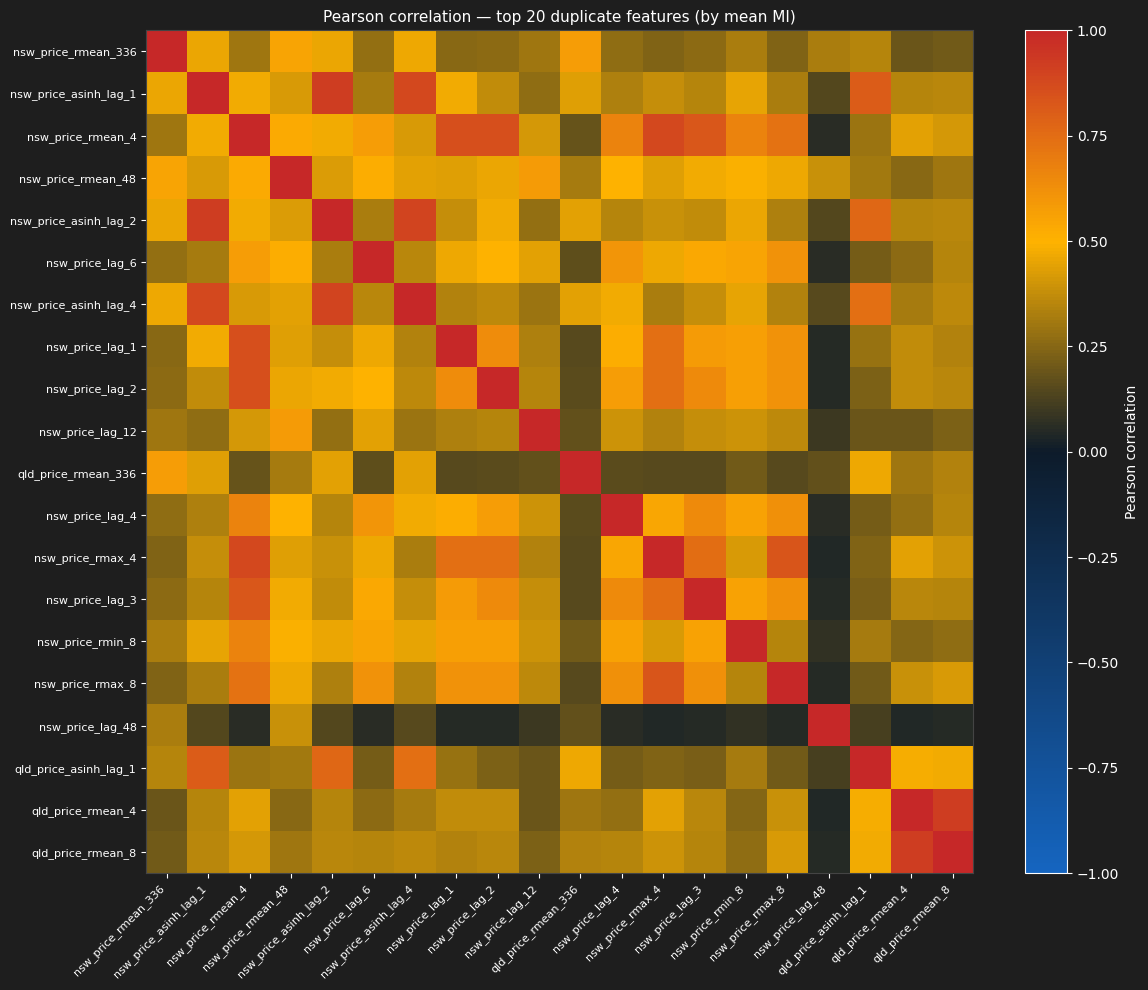

In [9]:
if True:
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap

    TOP_N = 20

    # Top N duplicate features by mean MI (highest MI duplicates — most "interesting" redundancies)
    duplicate_features = (
        feature_data_flagged[feature_data_flagged["is_duplicate"] == True]
        .head(TOP_N)["feature"]
        .tolist()
    )
    top_features = [f for f in duplicate_features if f in features_subsampled.columns]
    corr = features_subsampled[top_features].corr(method="pearson")

    # Diverging colormap with accent at 75th percentile (0.5 on the -1→1 scale = position 0.75)
    # blue → navy (mid) → electric cyan accent → crimson
    _cmap = LinearSegmentedColormap.from_list(
        "dark_div_accent",
        [
            (0.00, "#1565C0"),   # -1.0  deep blue
            (0.50, "#0D1B2A"),   #  0.0  dark navy (midpoint)
            (0.75, "#FFB300"),   # +0.5  electric cyan accent (75th percentile)
            (1.00, "#C62828"),   # +1.0  deep crimson
        ],
    )

    with plt.style.context("dark_background"):
        fig, ax = plt.subplots(figsize=(12, 10), facecolor="#1e1e1e")
        ax.set_facecolor("#1e1e1e")
        im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap=_cmap, aspect="auto")
        cbar = plt.colorbar(im, ax=ax, label="Pearson correlation")
        cbar.ax.yaxis.label.set_color("white")
        cbar.ax.tick_params(colors="white")
        ax.set_xticks(range(len(top_features)))
        ax.set_yticks(range(len(top_features)))
        ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8, color="white")
        ax.set_yticklabels(corr.index, fontsize=8, color="white")
        ax.set_title(f"Pearson correlation — top {len(top_features)} duplicate features (by mean MI)", fontsize=11, color="white")
        ax.tick_params(colors="white")
        for spine in ax.spines.values():
            spine.set_edgecolor("#444444")
        plt.tight_layout()
        plt.show()


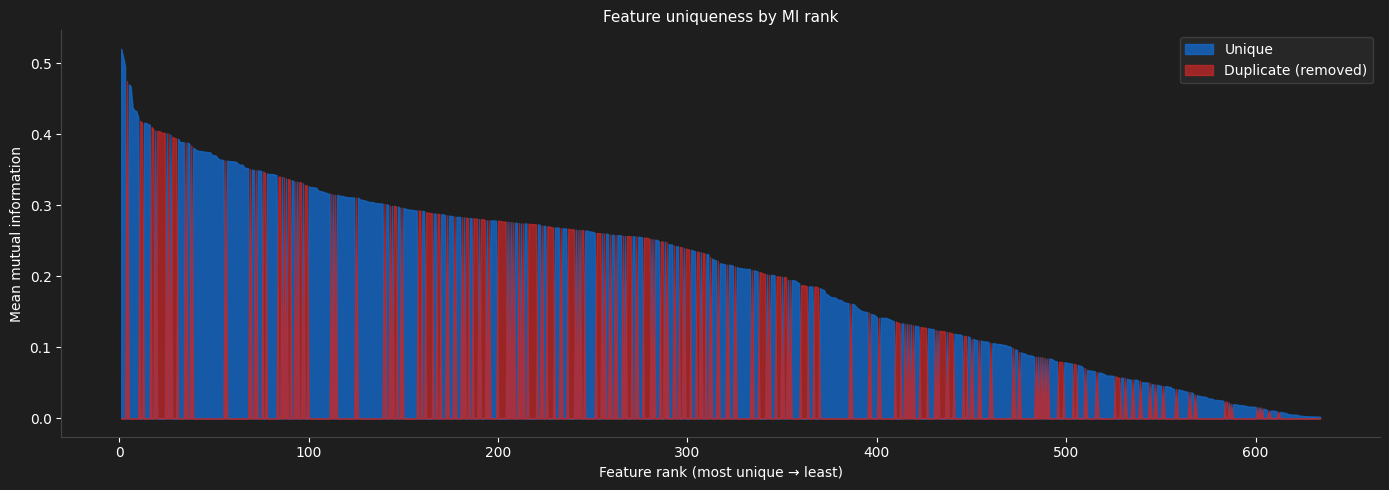

In [10]:
if True:
    import matplotlib.pyplot as plt

    df_plot = feature_data_flagged.sort_values("mean_mi", ascending=False).reset_index(drop=True)
    df_plot["rank_pos"] = range(1, len(df_plot) + 1)

    unique_mi = df_plot["mean_mi"].where(df_plot["is_duplicate"] == False, 0)
    dup_mi = df_plot["mean_mi"].where(df_plot["is_duplicate"] == True, 0)

    with plt.style.context("dark_background"):
        fig, ax = plt.subplots(figsize=(14, 5), facecolor="#1e1e1e")
        ax.set_facecolor("#1e1e1e")

        ax.fill_between(df_plot["rank_pos"], unique_mi, alpha=0.85, color="#1565C0", label="Unique")
        ax.fill_between(df_plot["rank_pos"], dup_mi, alpha=0.75, color="#C62828", label="Duplicate (removed)")

        ax.set_xlabel("Feature rank (most unique → least)", color="white", fontsize=10)
        ax.set_ylabel("Mean mutual information", color="white", fontsize=10)
        ax.set_title("Feature uniqueness by MI rank", fontsize=11, color="white")
        ax.tick_params(colors="white")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_edgecolor("#444444")
        ax.spines["left"].set_edgecolor("#444444")
        ax.legend(facecolor="#2a2a2a", edgecolor="#444444", labelcolor="white")
        plt.tight_layout()
        plt.show()


Feature selection

In [11]:
if True:
    def feature_data_selection(
        feature_data,
        features,
        future_prediction_targets_agg,
        subsample_start: pd.Timestamp,
        subsample_end: pd.Timestamp,
        subsample_amount: int,
    ):
        # Number of equally-spaced k values to evaluate between 1 and n_available_features — tune this
        N_K_VALUES = 3
        # Number of equally-spaced horizons to evaluate — e.g. 10 tests every ~10th horizon; None = all
        N_HORIZON_STEPS = 5
        N_CV_SPLITS = 5   # time-series walk-forward folds
        # Thread count — each thread holds one X_h copy in the shared process heap (no worker spawning)
        N_PARALLEL_JOBS = min(_NCPU, 8)

        # Lightweight LightGBM for CV speed — not production params
        _LGBM_CV_PARAMS = {
            "objective": "regression_l1",
            "metric": "mae",
            "n_estimators": 500,       # high ceiling; early stopping exits well before this
            "learning_rate": 0.05,
            "num_leaves": 31,
            "min_child_samples": 20,
            "feature_fraction": 0.8,
            "bagging_fraction": 0.8,
            "bagging_freq": 5,
            "n_iter_no_change": 20,    # early stopping: halt if val MAE doesn't improve for 20 rounds
            "random_state": 42,
            "n_jobs": 1,               # parallelism handled externally by joblib
            "verbose": -1,
        }

        horizon_cols = [c for c in feature_data.columns if c.startswith("h") and c[1:].isdigit()]
        mi_matrix = feature_data.set_index("feature")[horizon_cols]  # (n_features, n_horizons)
        available_features = [f for f in mi_matrix.index if f in features.columns]  # Only keep features that exist in the in-memory features DataFrame

        # Time-range filter then random row subsample
        shared_idx = features.index.intersection(future_prediction_targets_agg.index)
        shared_idx = shared_idx[(shared_idx >= subsample_start) & (shared_idx <= subsample_end)]
        n_total = len(shared_idx)
        n_rows = min(subsample_amount, n_total)
        if n_rows < n_total:
            rng = np.random.default_rng(42)
            chosen = np.sort(rng.choice(n_total, size=n_rows, replace=False))
            shared_idx = shared_idx[chosen]
        print(f"CV subsample: {n_rows:,} rows (of {n_total:,} in range {subsample_start.date()} – {subsample_end.date()})", flush=True)

        # Arrays live in the main process; threads share them without copying (no pickling, no mmap needed)
        X_arr = features.loc[shared_idx, available_features].values.astype(np.float32)  # (n_rows, n_features)
        Y_arr = future_prediction_targets_agg.loc[shared_idx].values.astype(np.float32)  # (n_rows, n_horizons)
        mi_arr = mi_matrix.loc[available_features].values.astype(np.float32)             # (n_features, n_horizons)

        x_mb = X_arr.nbytes / 1e6
        print(f"X_arr: {X_arr.shape} ({x_mb:.0f} MB) | threads: {N_PARALLEL_JOBS}", flush=True)

        tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS)
        fold_indices = list(tscv.split(X_arr))  # pre-compute once

        # Equally-spaced grid from 1 → n_available_features, deduplicated and sorted
        k_grid = sorted(set(int(round(k)) for k in np.linspace(1, len(available_features), N_K_VALUES)))

        # Equally-spaced horizon indices to evaluate; None = all horizons
        n_h = len(horizon_cols)
        if N_HORIZON_STEPS is None or N_HORIZON_STEPS >= n_h:
            horizon_indices = list(range(n_h))
        else:
            horizon_indices = sorted(set(int(round(i)) for i in np.linspace(0, n_h - 1, N_HORIZON_STEPS)))

        n_tasks = len(horizon_indices) * len(k_grid) * len(fold_indices)
        print(
            f"Horizons: {len(horizon_indices)} of {n_h} | k grid: {k_grid} | folds: {len(fold_indices)} | "
            f"total tasks: {n_tasks}",
            flush=True,
        )

        # Per-fold worker — trains exactly one LightGBM model per call.
        # backend="threading": LightGBM fit() is pure C++ and releases the GIL, so threads get genuine
        # parallelism without spawning worker processes. Arrays are shared in the same heap — no pickling,
        # no memory-mapping, no worker heap accumulation between tasks.
        def _eval_horizon_k_fold(h_idx, k, fold_idx):
            import warnings
            warnings.filterwarnings("ignore", message="X does not have valid feature names", category=UserWarning)

            mi_scores = mi_arr[:, h_idx]
            top_k_idx = np.argsort(mi_scores)[::-1][:k]
            X_h = X_arr[:, top_k_idx]
            y = Y_arr[:, h_idx]

            train_idx, val_idx = fold_indices[fold_idx]
            y_tr, y_va = y[train_idx], y[val_idx]
            mask_tr = np.isfinite(y_tr)
            mask_va = np.isfinite(y_va)
            if mask_tr.sum() < 50 or mask_va.sum() < 10:
                return h_idx, k, fold_idx, None

            m = lgb.LGBMRegressor(**_LGBM_CV_PARAMS)
            m.fit(
                X_h[train_idx][mask_tr], y_tr[mask_tr],
                eval_set=[(X_h[val_idx][mask_va], y_va[mask_va])],
            )
            preds = m.predict(X_h[val_idx][mask_va])
            mae = float(np.mean(np.abs(y_va[mask_va] - preds)))
            del m, X_h
            return h_idx, k, fold_idx, mae

        tasks = [
            (h_idx, k, fold_idx)
            for h_idx in horizon_indices
            for k in k_grid
            for fold_idx in range(len(fold_indices))
        ]

        results_gen = Parallel(n_jobs=N_PARALLEL_JOBS, backend="threading", batch_size=1, return_as="generator_unordered")(
            delayed(_eval_horizon_k_fold)(h_idx, k, fold_idx)
            for h_idx, k, fold_idx in tasks
        )

        fold_mae_acc = {}
        for h_idx, k, fold_idx, mae in tqdm(results_gen, total=len(tasks), desc="CV feature search"):
            key = (h_idx, k)
            if key not in fold_mae_acc:
                fold_mae_acc[key] = []
            if mae is not None:
                fold_mae_acc[key].append(mae)

        cv_records = [
            {"horizon": horizon_cols[h_idx], "k": k, "cv_mae": float(np.mean(maes)) if maes else float("inf")}
            for (h_idx, k), maes in fold_mae_acc.items()
        ]

        cv_df = pd.DataFrame(cv_records)
        best_idx = cv_df.groupby("horizon")["cv_mae"].idxmin()
        horizon_best_k = cv_df.loc[best_idx].rename(columns={"k": "best_k"}).reset_index(drop=True)

        display(horizon_best_k)
        return horizon_best_k

    horizon_best_k = feature_data_selection(
        feature_data_unique,
        features,
        future_prediction_targets_agg,
        subsample_start=FEATURE_SELECTION_CV_SUBSAMPLE_START,
        subsample_end=FEATURE_SELECTION_CV_SUBSAMPLE_END,
        subsample_amount=FEATURE_SELECTION_CV_SUBSAMPLE_AMOUNT,
    )



CV subsample: 50,000 rows (of 420,769 in range 2019-01-01 – 2023-01-01)
X_arr: (50000, 438) (88 MB) | threads: 8
Horizons: 5 of 96 | k grid: [1, 220, 438] | folds: 5 | total tasks: 75


CV feature search: 100%|██████████| 75/75 [01:21<00:00,  1.08s/it]


,horizon,best_k,cv_mae
0,h1,438,22.073976
1,h25,220,39.178601
2,h49,220,38.892499
3,h72,220,47.356081
4,h96,220,42.478688


Feature selection output

In [12]:
if True:
    def feature_selection_output(horizon_best_k, feature_data_unique):
        horizon_cols = [c for c in feature_data_unique.columns if c.startswith("h") and c[1:].isdigit()]
        mi_matrix = feature_data_unique.set_index("feature")[horizon_cols]  # (n_features, n_horizons)

        # For each evaluated horizon, select the top-best_k features by MI score.
        # Horizons not evaluated by CV (subsampled out) carry no selection row → column stays False.
        selection = pd.DataFrame(False, index=mi_matrix.index, columns=horizon_cols)

        for _, row in horizon_best_k.iterrows():
            h = row["horizon"]
            k = int(row["best_k"])
            if h not in mi_matrix.columns:
                continue
            top_k_features = mi_matrix[h].nlargest(k).index
            selection.loc[top_k_features, h] = True

        n_any = selection.any(axis=1).sum()
        print(
            f"Selected features per horizon | "
            f"features in any horizon: {n_any} of {len(mi_matrix)} | "
            f"per-horizon range: {selection.sum().min()}–{selection.sum().max()}",
            flush=True,
        )

        selection.to_parquet(os.environ["selected_features_output"])
        display(selection[:3])
    
    feature_selection_output(horizon_best_k, feature_data_unique)



Selected features per horizon | features in any horizon: 438 of 438 | per-horizon range: 0–438


,h1,h2,h3,h4,h5,h6,h7,h8,h9,h10,h11,h12,h13,h14,h15,h16,h17,h18,h19,h20,h21,h22,h23,h24,h25,h26,h27,h28,h29,h30,h31,h32,h33,h34,h35,h36,h37,h38,h39,h40,h41,h42,h43,h44,h45,h46,h47,h48,h49,h50,h51,h52,h53,h54,h55,h56,h57,h58,h59,h60,h61,h62,h63,h64,h65,h66,h67,h68,h69,h70,h71,h72,h73,h74,h75,h76,h77,h78,h79,h80,h81,h82,h83,h84,h85,h86,h87,h88,h89,h90,h91,h92,h93,h94,h95,h96
feature,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
nsw_price_q90_336,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
nsw_price_asinh_rmean_336,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
nsw_price_rmean_2016,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
